# LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)
**MSSV:** 2374802010086

**Họ và tên:** Nguyễn Văn Tùng Dương

In [10]:
import subprocess, sys
subprocess.check_call(['uv', 'pip', 'install', 'opencv-python', 'matplotlib', 'numpy',
                        '--break-system-packages', '--python', sys.executable])

0

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as TungDuong

## Đọc và hiển thị ảnh gốc

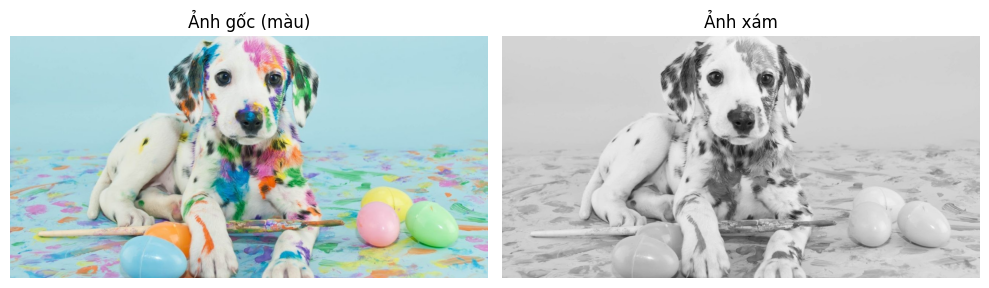

In [12]:
# Đọc ảnh
img = cv.imread('hinh1.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

TungDuong.figure(figsize=(10, 4))
TungDuong.subplot(1, 2, 1)
TungDuong.imshow(img_rgb)
TungDuong.title('Ảnh gốc (màu)')
TungDuong.axis('off')

TungDuong.subplot(1, 2, 2)
TungDuong.imshow(img_gray, cmap='gray')
TungDuong.title('Ảnh xám')
TungDuong.axis('off')
TungDuong.tight_layout()
TungDuong.show()

---
## 1. Thresholding để phân đoạn ảnh

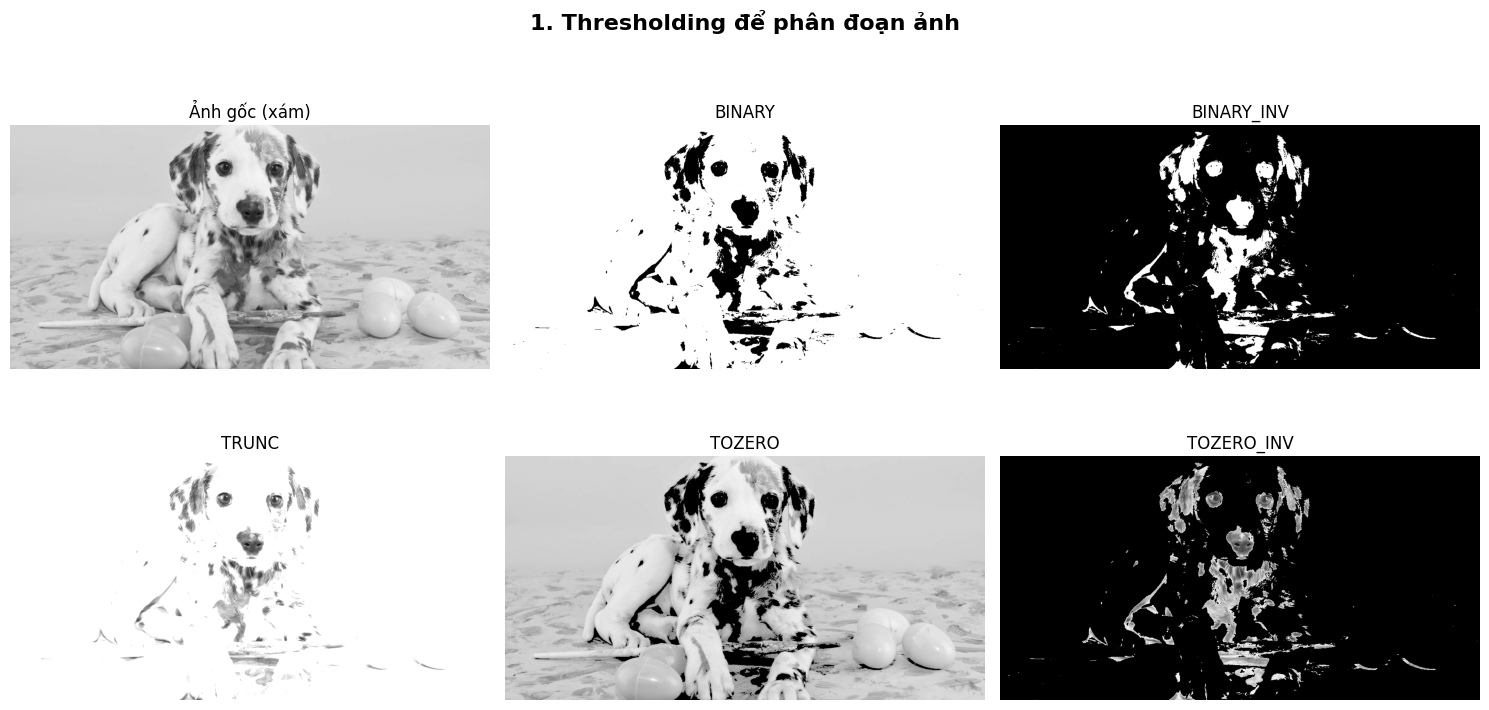

In [13]:
# 1.1. Binary Thresholding
ret1, thresh_binary = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

# 1.2. Binary Inverse Thresholding
ret2, thresh_binary_inv = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY_INV)

# 1.3. Truncate Thresholding
ret3, thresh_trunc = cv.threshold(img_gray, 127, 255, cv.THRESH_TRUNC)

# 1.4. To Zero Thresholding
ret4, thresh_tozero = cv.threshold(img_gray, 127, 255, cv.THRESH_TOZERO)

# 1.5. To Zero Inverse Thresholding
ret5, thresh_tozero_inv = cv.threshold(img_gray, 127, 255, cv.THRESH_TOZERO_INV)

# Hiển thị kết quả
titles = ['Ảnh gốc (xám)', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img_gray, thresh_binary, thresh_binary_inv, thresh_trunc, thresh_tozero, thresh_tozero_inv]

TungDuong.figure(figsize=(15, 8))
for i in range(6):
    TungDuong.subplot(2, 3, i + 1)
    TungDuong.imshow(images[i], cmap='gray')
    TungDuong.title(titles[i])
    TungDuong.axis('off')
TungDuong.suptitle('1. Thresholding để phân đoạn ảnh', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

### Adaptive Thresholding

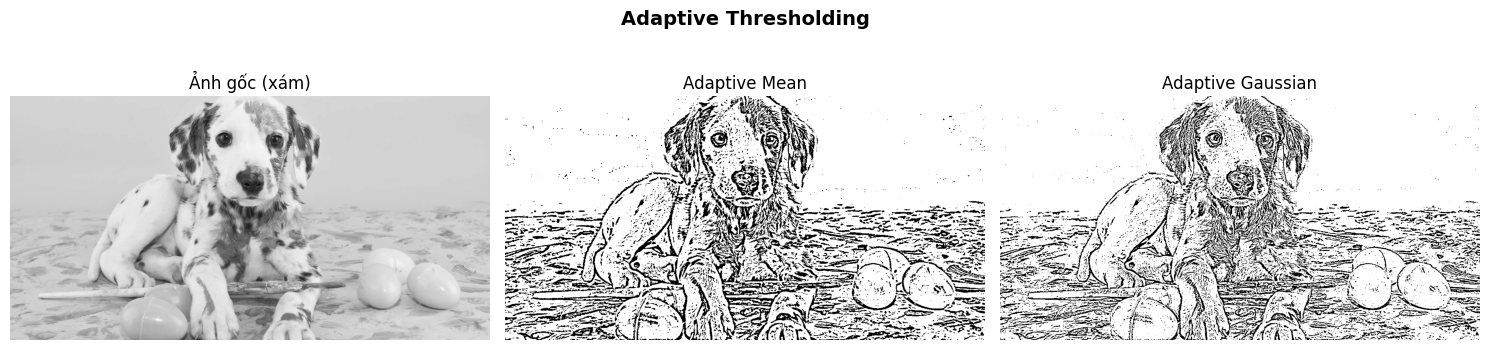

In [14]:
# Adaptive Mean Thresholding
adaptive_mean = cv.adaptiveThreshold(img_gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)

# Adaptive Gaussian Thresholding
adaptive_gaussian = cv.adaptiveThreshold(img_gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

TungDuong.figure(figsize=(15, 4))
TungDuong.subplot(1, 3, 1)
TungDuong.imshow(img_gray, cmap='gray')
TungDuong.title('Ảnh gốc (xám)')
TungDuong.axis('off')

TungDuong.subplot(1, 3, 2)
TungDuong.imshow(adaptive_mean, cmap='gray')
TungDuong.title('Adaptive Mean')
TungDuong.axis('off')

TungDuong.subplot(1, 3, 3)
TungDuong.imshow(adaptive_gaussian, cmap='gray')
TungDuong.title('Adaptive Gaussian')
TungDuong.axis('off')
TungDuong.suptitle('Adaptive Thresholding', fontsize=14, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 2. Otsu Algorithm để phân đoạn ảnh vân tay

Ngưỡng Otsu tự động chọn: 157.0
Ngưỡng Otsu sau Gaussian Blur: 159.0


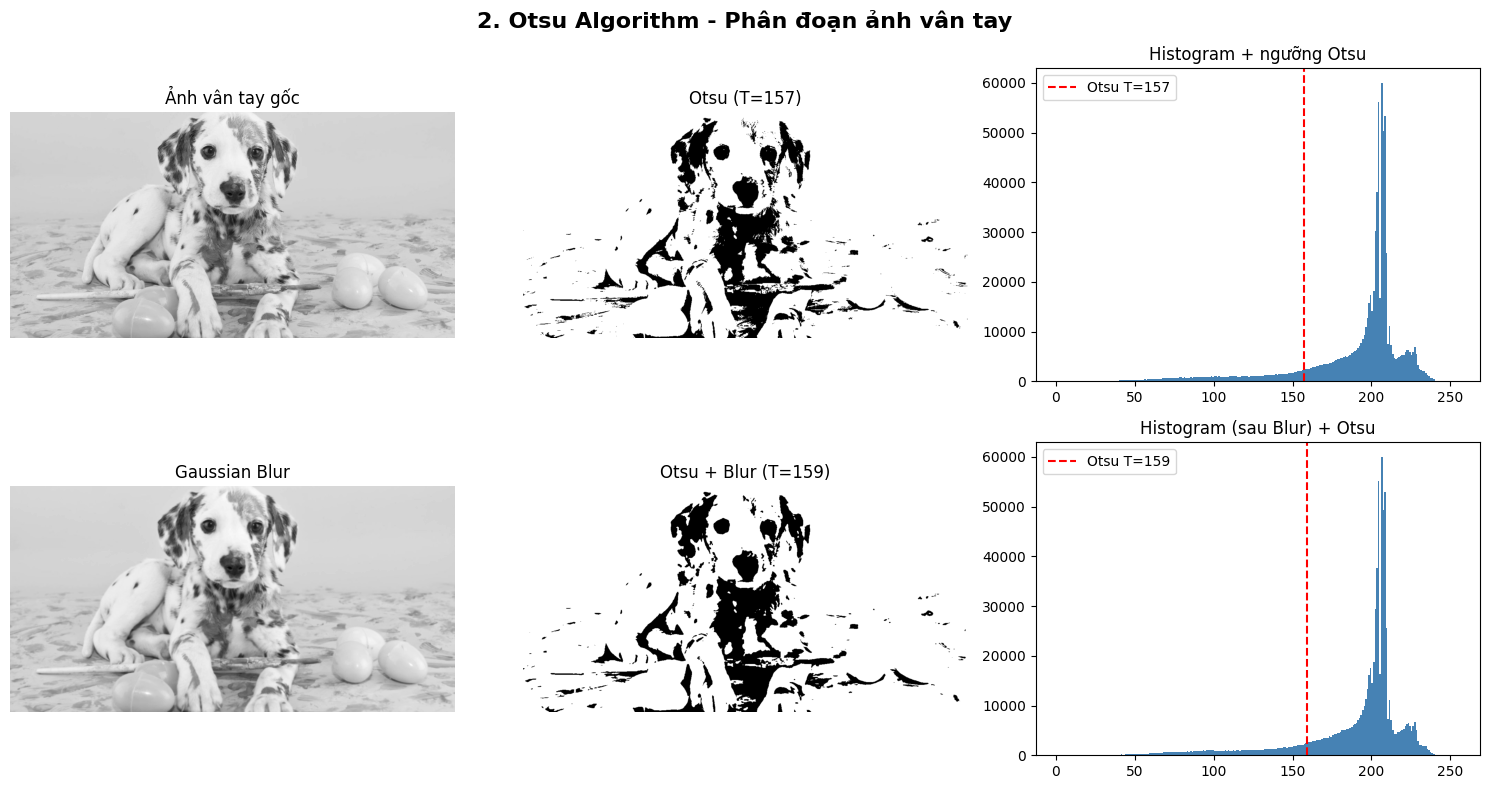

In [15]:
# Đọc ảnh vân tay (sử dụng hinh2.jpg)
img2 = cv.imread('hinh2.jpg')
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

# Áp dụng Otsu's Thresholding
ret_otsu, thresh_otsu = cv.threshold(img2_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print(f"Ngưỡng Otsu tự động chọn: {ret_otsu}")

# Áp dụng Gaussian Blur trước rồi Otsu
blur = cv.GaussianBlur(img2_gray, (5, 5), 0)
ret_otsu2, thresh_otsu2 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print(f"Ngưỡng Otsu sau Gaussian Blur: {ret_otsu2}")

# Hiển thị kết quả
TungDuong.figure(figsize=(15, 8))

TungDuong.subplot(2, 3, 1)
TungDuong.imshow(img2_gray, cmap='gray')
TungDuong.title('Ảnh vân tay gốc')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 2)
TungDuong.imshow(thresh_otsu, cmap='gray')
TungDuong.title(f'Otsu (T={ret_otsu:.0f})')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 3)
TungDuong.hist(img2_gray.ravel(), 256, [0, 256], color='steelblue')
TungDuong.axvline(x=ret_otsu, color='red', linestyle='--', label=f'Otsu T={ret_otsu:.0f}')
TungDuong.title('Histogram + ngưỡng Otsu')
TungDuong.legend()

TungDuong.subplot(2, 3, 4)
TungDuong.imshow(blur, cmap='gray')
TungDuong.title('Gaussian Blur')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 5)
TungDuong.imshow(thresh_otsu2, cmap='gray')
TungDuong.title(f'Otsu + Blur (T={ret_otsu2:.0f})')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 6)
TungDuong.hist(blur.ravel(), 256, [0, 256], color='steelblue')
TungDuong.axvline(x=ret_otsu2, color='red', linestyle='--', label=f'Otsu T={ret_otsu2:.0f}')
TungDuong.title('Histogram (sau Blur) + Otsu')
TungDuong.legend()

TungDuong.suptitle('2. Otsu Algorithm - Phân đoạn ảnh vân tay', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 3. Clustering Techniques - K-Means Clustering

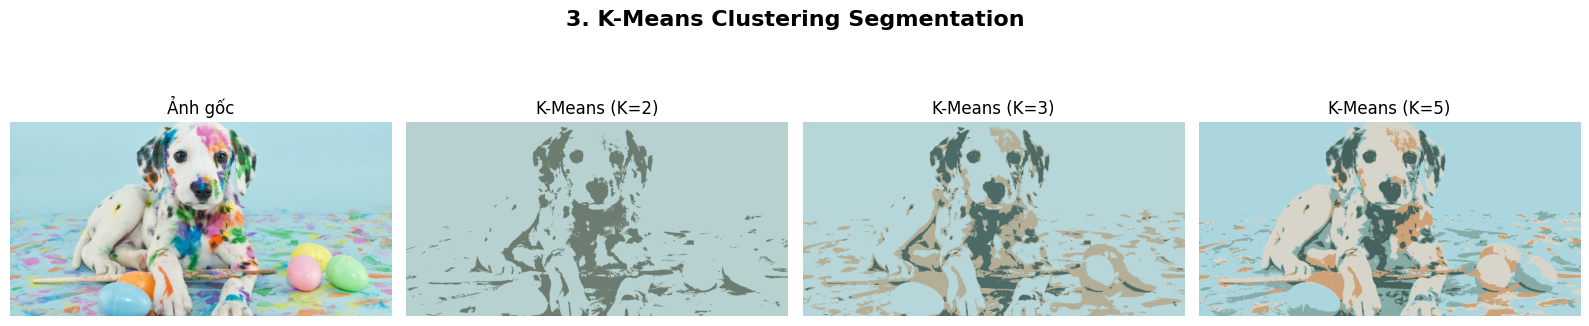

In [16]:
# Chuyển ảnh thành mảng 2D (mỗi pixel là 1 hàng với 3 giá trị BGR)
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Định nghĩa tiêu chí dừng
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Thử với K = 2, 3, 5
k_values = [2, 3, 5]

TungDuong.figure(figsize=(16, 4))
TungDuong.subplot(1, len(k_values) + 1, 1)
TungDuong.imshow(img_rgb)
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

for idx, k in enumerate(k_values):
    _, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(img.shape)
    segmented_image_rgb = cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB)

    TungDuong.subplot(1, len(k_values) + 1, idx + 2)
    TungDuong.imshow(segmented_image_rgb)
    TungDuong.title(f'K-Means (K={k})')
    TungDuong.axis('off')

TungDuong.suptitle('3. K-Means Clustering Segmentation', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 4. Region Growing

In [17]:
def region_growing(img, seed, threshold=10):
    """
    Thuật toán Region Growing
    - img: ảnh xám đầu vào
    - seed: điểm bắt đầu (y, x)
    - threshold: ngưỡng chênh lệch cường độ
    """
    h, w = img.shape
    segmented = np.zeros_like(img)
    visited = np.zeros((h, w), dtype=bool)

    seed_value = int(img[seed[0], seed[1]])
    stack = [seed]
    visited[seed[0], seed[1]] = True

    # 8-connected neighbors
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 (0, -1),           (0, 1),
                 (1, -1),  (1, 0),  (1, 1)]

    while stack:
        y, x = stack.pop()
        segmented[y, x] = 255

        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny][nx]:
                visited[ny][nx] = True
                if abs(int(img[ny, nx]) - seed_value) < threshold:
                    stack.append((ny, nx))

    return segmented

Seed point: (325, 640)
Giá trị pixel tại seed: 44


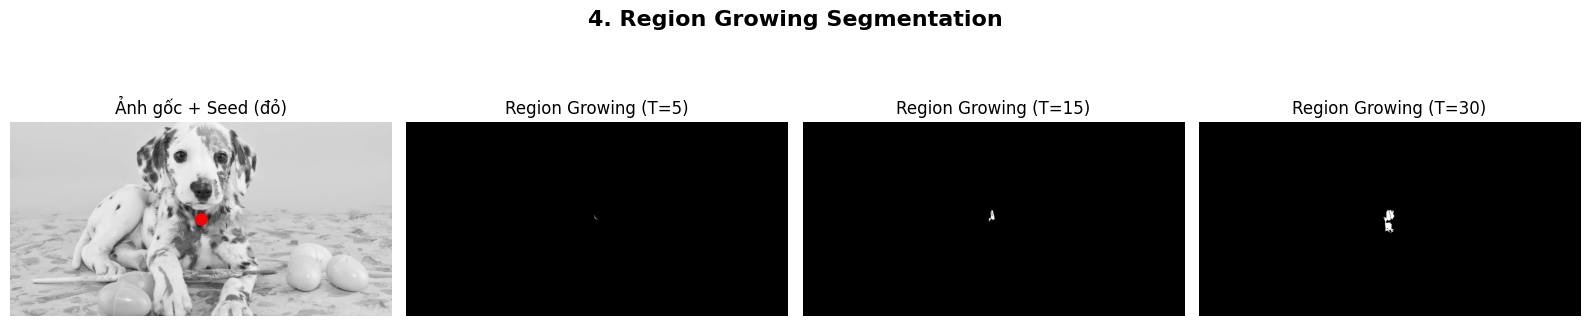

In [18]:
# Chọn điểm seed ở giữa ảnh
h, w = img_gray.shape
seed_point = (h // 2, w // 2)
print(f"Seed point: {seed_point}")
print(f"Giá trị pixel tại seed: {img_gray[seed_point[0], seed_point[1]]}")

# Áp dụng Region Growing với các ngưỡng khác nhau
thresholds = [5, 15, 30]

TungDuong.figure(figsize=(16, 4))
TungDuong.subplot(1, len(thresholds) + 1, 1)
TungDuong.imshow(img_gray, cmap='gray')
TungDuong.plot(seed_point[1], seed_point[0], 'ro', markersize=8)
TungDuong.title('Ảnh gốc + Seed (đỏ)')
TungDuong.axis('off')

for idx, t in enumerate(thresholds):
    result = region_growing(img_gray, seed_point, threshold=t)
    TungDuong.subplot(1, len(thresholds) + 1, idx + 2)
    TungDuong.imshow(result, cmap='gray')
    TungDuong.title(f'Region Growing (T={t})')
    TungDuong.axis('off')

TungDuong.suptitle('4. Region Growing Segmentation', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 5. Split and Merge

In [19]:
def split_and_merge(img, threshold=15, min_size=4):
    """
    Thuật toán Split and Merge để phân đoạn ảnh
    - img: ảnh xám đầu vào
    - threshold: ngưỡng đồng nhất (std deviation)
    - min_size: kích thước nhỏ nhất của vùng
    """
    h, w = img.shape
    output = np.zeros_like(img)

    def is_homogeneous(region):
        """Kiểm tra vùng có đồng nhất không"""
        return np.std(region) < threshold

    def split(y, x, size):
        """Chia vùng thành 4 phần nếu không đồng nhất"""
        region = img[y:y+size, x:x+size]

        if is_homogeneous(region) or size <= min_size:
            # Merge: gán giá trị trung bình cho toàn bộ vùng
            output[y:y+size, x:x+size] = np.mean(region)
        else:
            half = size // 2
            if half < 1:
                output[y:y+size, x:x+size] = np.mean(region)
                return
            # Split thành 4 quadrant
            split(y, x, half)                # Top-left
            split(y, x + half, half)          # Top-right
            split(y + half, x, half)          # Bottom-left
            split(y + half, x + half, half)   # Bottom-right

    # Resize ảnh thành kích thước 2^n x 2^n
    n = min(h, w)
    power = 1
    while power * 2 <= n:
        power *= 2

    img_resized = cv.resize(img, (power, power))
    output = np.zeros_like(img_resized)

    # Tăng giới hạn đệ quy
    import sys
    sys.setrecursionlimit(100000)

    split(0, 0, power)

    # Resize lại kích thước gốc
    output = cv.resize(output, (w, h))
    return output

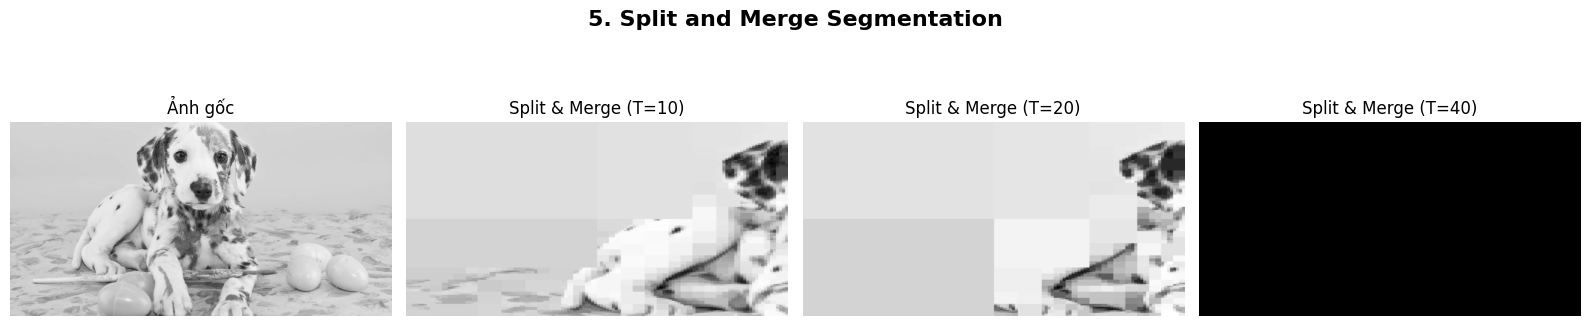

In [20]:
# Áp dụng Split and Merge với các ngưỡng khác nhau
thresholds_sm = [10, 20, 40]

TungDuong.figure(figsize=(16, 4))
TungDuong.subplot(1, len(thresholds_sm) + 1, 1)
TungDuong.imshow(img_gray, cmap='gray')
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

for idx, t in enumerate(thresholds_sm):
    result_sm = split_and_merge(img_gray, threshold=t, min_size=4)
    TungDuong.subplot(1, len(thresholds_sm) + 1, idx + 2)
    TungDuong.imshow(result_sm, cmap='gray')
    TungDuong.title(f'Split & Merge (T={t})')
    TungDuong.axis('off')

TungDuong.suptitle('5. Split and Merge Segmentation', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 6. Edge-based Segmentation

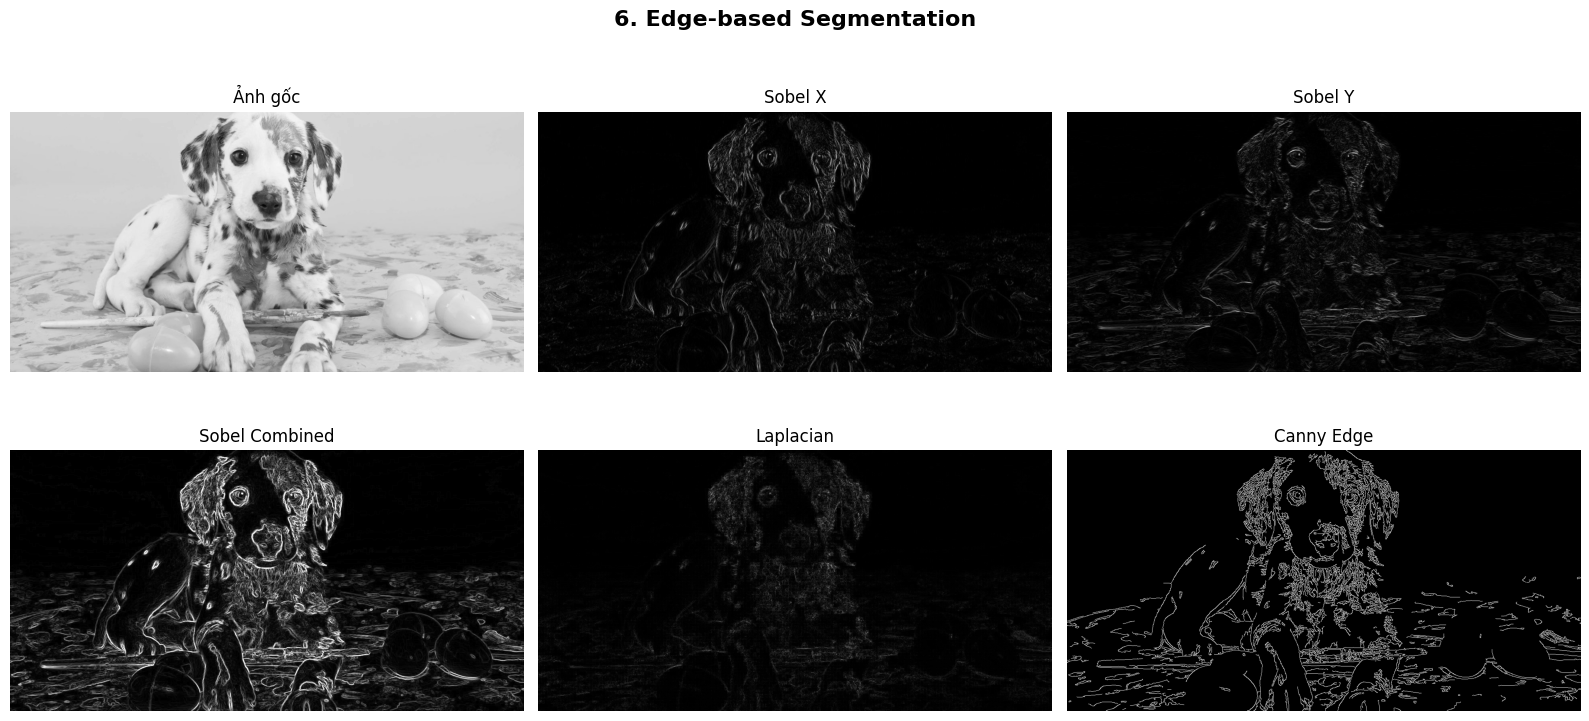

In [21]:
# 6.1. Sobel Edge Detection
sobel_x = cv.Sobel(img_gray, cv.CV_64F, 1, 0, ksize=3)
sobel_y = cv.Sobel(img_gray, cv.CV_64F, 0, 1, ksize=3)
sobel_combined = cv.magnitude(sobel_x, sobel_y)
sobel_combined = np.uint8(np.clip(sobel_combined, 0, 255))

# 6.2. Laplacian Edge Detection
laplacian = cv.Laplacian(img_gray, cv.CV_64F)
laplacian = np.uint8(np.abs(laplacian))

# 6.3. Canny Edge Detection
canny = cv.Canny(img_gray, 50, 150)

# Hiển thị
TungDuong.figure(figsize=(16, 8))

TungDuong.subplot(2, 3, 1)
TungDuong.imshow(img_gray, cmap='gray')
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 2)
TungDuong.imshow(np.abs(sobel_x), cmap='gray')
TungDuong.title('Sobel X')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 3)
TungDuong.imshow(np.abs(sobel_y), cmap='gray')
TungDuong.title('Sobel Y')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 4)
TungDuong.imshow(sobel_combined, cmap='gray')
TungDuong.title('Sobel Combined')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 5)
TungDuong.imshow(laplacian, cmap='gray')
TungDuong.title('Laplacian')
TungDuong.axis('off')

TungDuong.subplot(2, 3, 6)
TungDuong.imshow(canny, cmap='gray')
TungDuong.title('Canny Edge')
TungDuong.axis('off')

TungDuong.suptitle('6. Edge-based Segmentation', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

### Edge-based Segmentation kết hợp với Morphological Operations

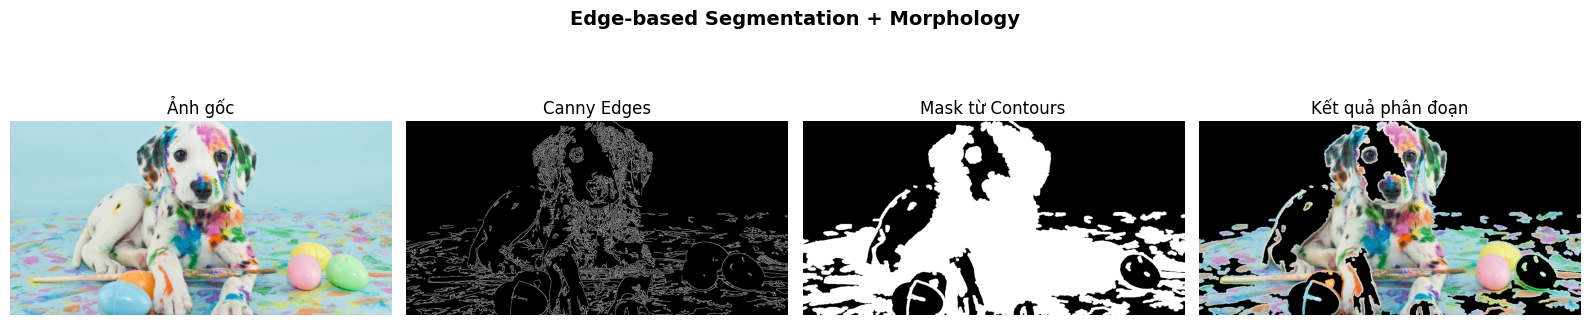

In [22]:
# Sử dụng Canny + Morphological để tạo mask phân đoạn
# Phát hiện cạnh bằng Canny
edges = cv.Canny(img_gray, 30, 100)

# Dilate để nối các cạnh
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
dilated = cv.dilate(edges, kernel, iterations=2)

# Tìm contours
contours, _ = cv.findContours(dilated, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Tạo mask từ contours
mask = np.zeros_like(img_gray)
cv.drawContours(mask, contours, -1, 255, -1)

# Áp dụng mask lên ảnh gốc
result_edge = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

TungDuong.figure(figsize=(16, 4))

TungDuong.subplot(1, 4, 1)
TungDuong.imshow(img_rgb)
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

TungDuong.subplot(1, 4, 2)
TungDuong.imshow(edges, cmap='gray')
TungDuong.title('Canny Edges')
TungDuong.axis('off')

TungDuong.subplot(1, 4, 3)
TungDuong.imshow(mask, cmap='gray')
TungDuong.title('Mask từ Contours')
TungDuong.axis('off')

TungDuong.subplot(1, 4, 4)
TungDuong.imshow(result_edge)
TungDuong.title('Kết quả phân đoạn')
TungDuong.axis('off')

TungDuong.suptitle('Edge-based Segmentation + Morphology', fontsize=14, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()